In [ ]:
!pip -q install opencv-python-headless scikit-learn matplotlib tqdm

import os
import re
import glob
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

tf.get_logger().setLevel("ERROR")
print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

SEARCH_ROOT = "/content/drive/MyDrive"
ZIP_PATH = os.path.join(SEARCH_ROOT, "IDRID_DATASET.zip")

if os.path.exists(ZIP_PATH):
    print("Zip found. Extracting...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(SEARCH_ROOT)
    print("Done.")

def find_idrid_root(search_root):
    for dirpath, dirnames, filenames in os.walk(search_root):
        if "1. Original Images" in dirnames and "2. All Segmentation Groundtruths" in dirnames:
            return dirpath
    raise FileNotFoundError("IDRiD segmentation root not found.")

SEG_ROOT = find_idrid_root(SEARCH_ROOT)
print("SEG_ROOT:", SEG_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Zip found. Extracting...
Done.
SEG_ROOT: /content/drive/MyDrive/IDRID_DATASET/A.%20Segmentation/A. Segmentation


In [ ]:
CLASS_INFO = {
    1: ("MA", "1. Microaneurysms"),
    2: ("HE", "2. Haemorrhages"),
    3: ("EX", "3. Hard Exudates"),
    4: ("SE", "4. Soft Exudates"),
    5: ("OD", "5. Optic Disc"),
}

CLASS_NAMES = {
    0: "Background",
    1: "Microaneurysm",
    2: "Hemorrhage",
    3: "Hard Exudate",
    4: "Soft Exudate",
    5: "Optic Disc",
}

num_classes = 6
lesion_classes = [1, 2, 3, 4, 5]

train_img_dir = os.path.join(SEG_ROOT, "1. Original Images", "a. Training Set")
test_img_dir  = os.path.join(SEG_ROOT, "1. Original Images", "b. Testing Set")

train_mask_root = os.path.join(SEG_ROOT, "2. All Segmentation Groundtruths", "a. Training Set")
test_mask_root  = os.path.join(SEG_ROOT, "2. All Segmentation Groundtruths", "b. Testing Set")

print("Train image dir:", train_img_dir)
print("Test image dir :", test_img_dir)
print("Train mask root :", train_mask_root)
print("Test mask root  :", test_mask_root)

def get_id_from_name(path):
    m = re.search(r"IDRiD_(\d+)", os.path.basename(path))
    return int(m.group(1)) if m else None

def build_records(img_dir, mask_root):
    exts = ("*.jpg", "*.jpeg", "*.png", "*.tif", "*.tiff")
    img_paths = []
    for ext in exts:
        img_paths.extend(glob.glob(os.path.join(img_dir, ext)))
    img_paths = sorted(img_paths)

    records = []
    for img_path in img_paths:
        img_id = get_id_from_name(img_path)
        masks = {}
        for class_id, (abbr, folder_name) in CLASS_INFO.items():
            mask_path = os.path.join(mask_root, folder_name, f"IDRiD_{img_id:02d}_{abbr}.tif")
            masks[class_id] = mask_path if os.path.exists(mask_path) else None
        records.append({"id": img_id, "image_path": img_path, "masks": masks})
    return records

train_records = build_records(train_img_dir, train_mask_root)
test_records  = build_records(test_img_dir, test_mask_root)

print("Train images:", len(train_records))
print("Test images :", len(test_records))

for cid, cname in CLASS_NAMES.items():
    if cid == 0:
        continue
    miss_train = sum(1 for r in train_records if r["masks"][cid] is None)
    miss_test  = sum(1 for r in test_records if r["masks"][cid] is None)
    print(f"{cname}: missing train masks = {miss_train}, missing test masks = {miss_test}")

Train image dir: /content/drive/MyDrive/IDRID_DATASET/A.%20Segmentation/A. Segmentation/1. Original Images/a. Training Set
Test image dir : /content/drive/MyDrive/IDRID_DATASET/A.%20Segmentation/A. Segmentation/1. Original Images/b. Testing Set
Train mask root : /content/drive/MyDrive/IDRID_DATASET/A.%20Segmentation/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set
Test mask root  : /content/drive/MyDrive/IDRID_DATASET/A.%20Segmentation/A. Segmentation/2. All Segmentation Groundtruths/b. Testing Set
Train images: 54
Test images : 27
Microaneurysm: missing train masks = 0, missing test masks = 0
Hemorrhage: missing train masks = 1, missing test masks = 0
Hard Exudate: missing train masks = 0, missing test masks = 0
Soft Exudate: missing train masks = 28, missing test masks = 13
Optic Disc: missing train masks = 0, missing test masks = 0


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TARGET_SIZE = 1024
PATCH_SIZE = 256
BATCH_SIZE = 8

train_recs, val_recs = train_test_split(
    train_records, test_size=0.15, random_state=SEED, shuffle=True
)

print("Train split:", len(train_recs))
print("Val split  :", len(val_recs))
print("Test split :", len(test_records))

Train split: 45
Val split  : 9
Test split : 27


In [ ]:
def read_rgb(path):
    return np.array(Image.open(path).convert("RGB"))

def read_mask_gray(path):
    if path is None or (not os.path.exists(path)):
        return None
    m = np.array(Image.open(path).convert("L"))
    return (m > 0).astype(np.uint8)

def crop_to_retina_box(rgb_img):
    gray = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2GRAY)
    mask = gray > 10
    if mask.sum() == 0:
        h, w = gray.shape
        return 0, 0, w, h
    ys, xs = np.where(mask)
    x0, y0 = xs.min(), ys.min()
    x1, y1 = xs.max() + 1, ys.max() + 1
    margin = 30
    h, w = gray.shape
    x0 = max(0, x0 - margin)
    y0 = max(0, y0 - margin)
    x1 = min(w, x1 + margin)
    y1 = min(h, y1 + margin)
    return x0, y0, x1, y1

def apply_clahe_rgb(rgb_img):
    lab = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge([l, a, b])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def resize_and_pad(img, target_size=1024, is_mask=False):
    h, w = img.shape[:2]
    scale = min(target_size / w, target_size / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interp = cv2.INTER_NEAREST if is_mask else cv2.INTER_AREA
    resized = cv2.resize(img, (new_w, new_h), interpolation=interp)

    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left

    if img.ndim == 2:
        padded = cv2.copyMakeBorder(
            resized, pad_top, pad_bottom, pad_left, pad_right,
            cv2.BORDER_CONSTANT, value=0
        )
    else:
        padded = cv2.copyMakeBorder(
            resized, pad_top, pad_bottom, pad_left, pad_right,
            cv2.BORDER_CONSTANT, value=(0, 0, 0)
        )
    return padded

def combine_masks(mask_paths_dict, shape_hw):
    h, w = shape_hw
    combined = np.zeros((h, w), dtype=np.uint8)
    priority = [1, 4, 2, 3, 5]
    for class_id in priority:
        path = mask_paths_dict.get(class_id, None)
        m = read_mask_gray(path)
        if m is None:
            continue
        if m.shape != (h, w):
            m = cv2.resize(m.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
        combined[m > 0] = class_id
    return combined

def preprocess_image_and_mask(rgb_img, label_mask):
    x0, y0, x1, y1 = crop_to_retina_box(rgb_img)
    rgb_crop = rgb_img[y0:y1, x0:x1]
    mask_crop = label_mask[y0:y1, x0:x1]
    rgb_crop = apply_clahe_rgb(rgb_crop)
    rgb_pp = resize_and_pad(rgb_crop, TARGET_SIZE, is_mask=False)
    mask_pp = resize_and_pad(mask_crop, TARGET_SIZE, is_mask=True)
    return rgb_pp, mask_pp

def make_boundary_mask(label_mask):
    union = (label_mask > 0).astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)
    boundary = cv2.morphologyEx(union, cv2.MORPH_GRADIENT, kernel)
    return (boundary > 0).astype(np.uint8)

def class_presence_from_mask(mask):
    return np.array([1.0 if np.any(mask == c) else 0.0 for c in lesion_classes], dtype=np.float32)

def crop_around_point(arr, cx, cy, crop_size, is_mask=False):
    h, w = arr.shape[:2]
    half = crop_size // 2

    x1 = int(round(cx - half))
    y1 = int(round(cy - half))
    x2 = x1 + crop_size
    y2 = y1 + crop_size

    pad_left = max(0, -x1)
    pad_top = max(0, -y1)
    pad_right = max(0, x2 - w)
    pad_bottom = max(0, y2 - h)

    x1c = max(0, x1)
    y1c = max(0, y1)
    x2c = min(w, x2)
    y2c = min(h, y2)

    crop = arr[y1c:y2c, x1c:x2c]

    if pad_left or pad_right or pad_top or pad_bottom:
        border_val = 0 if (is_mask or arr.ndim == 2) else (0, 0, 0)
        crop = cv2.copyMakeBorder(
            crop, pad_top, pad_bottom, pad_left, pad_right,
            cv2.BORDER_CONSTANT, value=border_val
        )
    return crop

def sample_crop_size(class_id, rng, training=True):
    if class_id == 1:
        return int(rng.choice([128, 160], p=[0.75, 0.25]) if training else 160)
    if class_id == 2:
        return int(rng.choice([160, 192], p=[0.65, 0.35]) if training else 192)
    if class_id in [3, 4]:
        return int(rng.choice([192, 224], p=[0.60, 0.40]) if training else 224)
    if class_id == 5:
        return int(rng.choice([224, 256], p=[0.55, 0.45]) if training else 256)
    return 256

def choose_center(mask, class_id, crop_size, rng):
    h, w = mask.shape
    half = crop_size // 2

    if class_id > 0:
        coords = np.argwhere(mask == class_id)
        if len(coords) > 0:
            y, x = coords[rng.integers(0, len(coords))]
            jitter = max(4, crop_size // 10)
            x = int(np.clip(x + rng.integers(-jitter, jitter + 1), half, w - half))
            y = int(np.clip(y + rng.integers(-jitter, jitter + 1), half, h - half))
            return x, y

    for _ in range(120):
        x = int(rng.integers(half, w - half))
        y = int(rng.integers(half, h - half))
        patch = crop_around_point(mask, x, y, crop_size, is_mask=True)
        if np.mean(patch > 0) < 0.005:
            return x, y

    return w // 2, h // 2

def extract_patch_from_full(img, mask, class_id, rng, training=True):
    crop_size = sample_crop_size(class_id, rng, training=training)
    cx, cy = choose_center(mask, class_id, crop_size, rng)
    img_crop = crop_around_point(img, cx, cy, crop_size, is_mask=False)
    mask_crop = crop_around_point(mask, cx, cy, crop_size, is_mask=True)

    img_patch = cv2.resize(img_crop, (PATCH_SIZE, PATCH_SIZE), interpolation=cv2.INTER_AREA)
    mask_patch = cv2.resize(mask_crop, (PATCH_SIZE, PATCH_SIZE), interpolation=cv2.INTER_NEAREST)
    return img_patch, mask_patch

def paste_lesion_object(src_img, src_mask, dst_img, dst_mask, rng):
    lesion_pixels = src_mask > 0
    if lesion_pixels.sum() == 0:
        return dst_img, dst_mask

    ys, xs = np.where(lesion_pixels)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()

    obj_img = src_img[y0:y1 + 1, x0:x1 + 1].copy()
    obj_mask = src_mask[y0:y1 + 1, x0:x1 + 1].copy()

    obj_h, obj_w = obj_mask.shape[:2]
    if obj_h >= PATCH_SIZE or obj_w >= PATCH_SIZE:
        return dst_img, dst_mask

    tx = int(rng.integers(0, PATCH_SIZE - obj_w + 1))
    ty = int(rng.integers(0, PATCH_SIZE - obj_h + 1))

    out_img = dst_img.copy()
    out_mask = dst_mask.copy()

    roi_img = out_img[ty:ty + obj_h, tx:tx + obj_w]
    roi_mask = out_mask[ty:ty + obj_h, tx:tx + obj_w]

    mask_bool = obj_mask > 0
    roi_img[mask_bool] = obj_img[mask_bool]
    roi_mask[mask_bool] = np.maximum(roi_mask[mask_bool], obj_mask[mask_bool])

    out_img[ty:ty + obj_h, tx:tx + obj_w] = roi_img
    out_mask[ty:ty + obj_h, tx:tx + obj_w] = roi_mask
    return out_img, out_mask

def augment_pair(img, mask, rng):
    if rng.random() < 0.5:
        img = np.fliplr(img).copy()
        mask = np.fliplr(mask).copy()

    if rng.random() < 0.5:
        img = np.flipud(img).copy()
        mask = np.flipud(mask).copy()

    k = int(rng.integers(0, 4))
    if k > 0:
        img = np.rot90(img, k).copy()
        mask = np.rot90(mask, k).copy()

    alpha = 1.0 + rng.uniform(-0.10, 0.10)
    beta = rng.uniform(-12, 12)
    img = np.clip(alpha * img + beta, 0, 255).astype(np.uint8)

    if rng.random() < 0.30:
        noise = rng.normal(0, 4, img.shape).astype(np.float32)
        img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    return img, mask

In [ ]:
def prepare_full_data(records, return_class_indices=False):
    images = []
    masks = []
    boundaries = []
    presences = []
    class_indices = {c: [] for c in lesion_classes}

    for i, rec in enumerate(tqdm(records, desc="Preprocessing")):
        img = read_rgb(rec["image_path"])
        h, w = img.shape[:2]
        combined = combine_masks(rec["masks"], (h, w))
        img_pp, mask_pp = preprocess_image_and_mask(img, combined)
        boundary_pp = make_boundary_mask(mask_pp)

        images.append(img_pp.astype(np.uint8))
        masks.append(mask_pp.astype(np.uint8))
        boundaries.append(boundary_pp.astype(np.uint8))
        presences.append(class_presence_from_mask(mask_pp))

        if return_class_indices:
            for c in lesion_classes:
                if np.any(mask_pp == c):
                    class_indices[c].append(i)

    images = np.array(images)
    masks = np.array(masks)
    boundaries = np.array(boundaries)
    presences = np.array(presences)

    if return_class_indices:
        return images, masks, boundaries, presences, class_indices
    return images, masks, boundaries, presences

train_imgs, train_masks, train_boundaries, train_presence, train_class_indices = prepare_full_data(
    train_recs, return_class_indices=True
)
val_imgs, val_masks, val_boundaries, val_presence = prepare_full_data(val_recs, return_class_indices=False)
test_imgs, test_masks, test_boundaries, test_presence = prepare_full_data(test_records, return_class_indices=False)

print("Train images:", train_imgs.shape)
print("Val images  :", val_imgs.shape)
print("Test images :", test_imgs.shape)
for c in lesion_classes:
    print(f"class {c} train images:", len(train_class_indices[c]))

Preprocessing: 100%|██████████| 27/27 [00:23<00:00,  1.14it/s]

Train images: (45, 1024, 1024, 3)
Val images  : (9, 1024, 1024, 3)
Test images : (27, 1024, 1024, 3)
class 1 train images: 45
class 2 train images: 44
class 3 train images: 45
class 4 train images: 21
class 5 train images: 45


In [ ]:
counts = np.zeros(num_classes, dtype=np.float64)
for mask in train_masks:
    counts += np.bincount(mask.flatten(), minlength=num_classes)

freq = counts / np.maximum(counts.sum(), 1.0)
weights = 1.0 / np.sqrt(freq + 1e-8)

weights[1] *= 2.5
weights[2] *= 1.5
weights[3] *= 1.3
weights[4] *= 1.3
weights[5] *= 1.1

weights = weights / weights.mean()
weights = np.clip(weights, 0.5, 8.0)
weights[0] = min(weights[0], 0.5)

print("Class counts :", np.round(counts, 2))
print("Class weights :", np.round(weights, 3))

class_weights_tf = tf.constant(weights.astype(np.float32))

Class counts : [45295493.    48256.   511567.   375749.    90963.   863892.]
Class weights : [0.5   3.215 0.592 0.599 1.218 0.5  ]


In [ ]:
class PatchSequence(tf.keras.utils.Sequence):
    def __init__(self, images, masks, class_indices, batch_size=8, steps_per_epoch=70, augment=True, seed=42):
        self.images = images
        self.masks = masks
        self.class_indices = class_indices
        self.batch_size = batch_size
        self.steps_per_epoch = steps_per_epoch
        self.augment = augment
        self.rng = np.random.default_rng(seed)

        self.class_probs = np.array([0.18, 0.42, 0.14, 0.10, 0.10, 0.06], dtype=np.float32)
        self.class_probs = self.class_probs / self.class_probs.sum()

    def __len__(self):
        return self.steps_per_epoch

    def __getitem__(self, idx):
        X = np.zeros((self.batch_size, PATCH_SIZE, PATCH_SIZE, 3), dtype=np.float32)
        Y_seg = np.zeros((self.batch_size, PATCH_SIZE, PATCH_SIZE, num_classes), dtype=np.float32)
        Y_bnd = np.zeros((self.batch_size, PATCH_SIZE, PATCH_SIZE, 1), dtype=np.float32)
        Y_ma = np.zeros((self.batch_size, PATCH_SIZE, PATCH_SIZE, 1), dtype=np.float32)
        Y_pre = np.zeros((self.batch_size, len(lesion_classes)), dtype=np.float32)

        for i in range(self.batch_size):
            target_class = int(self.rng.choice(np.array([0, 1, 2, 3, 4, 5]), p=self.class_probs))

            if target_class > 0 and len(self.class_indices[target_class]) > 0:
                src_idx = int(self.rng.choice(self.class_indices[target_class]))
            else:
                src_idx = int(self.rng.integers(0, len(self.images)))

            src_img = self.images[src_idx]
            src_mask = self.masks[src_idx]
            patch_img, patch_mask = extract_patch_from_full(src_img, src_mask, target_class, self.rng, training=True)

            if target_class > 0 and self.rng.random() < 0.60:
                bg_idx = int(self.rng.integers(0, len(self.images)))
                bg_img = self.images[bg_idx]
                bg_mask = self.masks[bg_idx]
                bg_patch_img, bg_patch_mask = extract_patch_from_full(bg_img, bg_mask, 0, self.rng, training=True)
                patch_img, patch_mask = paste_lesion_object(patch_img, patch_mask, bg_patch_img, bg_patch_mask, self.rng)

            if self.augment:
                patch_img, patch_mask = augment_pair(patch_img, patch_mask, self.rng)

            boundary = make_boundary_mask(patch_mask)
            ma_mask = (patch_mask == 1).astype(np.uint8)
            presence = class_presence_from_mask(patch_mask)

            X[i] = patch_img.astype(np.float32) / 255.0
            Y_seg[i] = tf.keras.utils.to_categorical(patch_mask, num_classes=num_classes).astype(np.float32)
            Y_bnd[i, :, :, 0] = boundary.astype(np.float32)
            Y_ma[i, :, :, 0] = ma_mask.astype(np.float32)
            Y_pre[i] = presence

        return X, {
            "segmentation": Y_seg,
            "boundary": Y_bnd,
            "ma_mask": Y_ma,
            "presence": Y_pre
        }

def build_eval_patches(images, masks, patches_per_image=4):
    rng = np.random.default_rng(SEED + 123)
    X, Y_seg, Y_bnd, Y_ma, Y_pre = [], [], [], [], []

    for img, mask in zip(images, masks):
        planned = [c for c in [1, 2, 3, 4, 5] if np.any(mask == c)]
        if len(planned) == 0:
            planned = [0]
        planned = planned[:patches_per_image]
        while len(planned) < patches_per_image:
            planned.append(0)

        for cls in planned:
            patch_img, patch_mask = extract_patch_from_full(img, mask, cls, rng, training=False)
            boundary = make_boundary_mask(patch_mask)
            ma_mask = (patch_mask == 1).astype(np.uint8)
            presence = class_presence_from_mask(patch_mask)

            X.append(patch_img.astype(np.float32) / 255.0)
            Y_seg.append(tf.keras.utils.to_categorical(patch_mask, num_classes=num_classes).astype(np.float32))
            Y_bnd.append(boundary.astype(np.float32)[..., None])
            Y_ma.append(ma_mask.astype(np.float32)[..., None])
            Y_pre.append(presence)

    X = np.array(X, dtype=np.float32)
    Y_seg = np.array(Y_seg, dtype=np.float32)
    Y_bnd = np.array(Y_bnd, dtype=np.float32)
    Y_ma = np.array(Y_ma, dtype=np.float32)
    Y_pre = np.array(Y_pre, dtype=np.float32)

    ds = tf.data.Dataset.from_tensor_slices((
        X,
        {
            "segmentation": Y_seg,
            "boundary": Y_bnd,
            "ma_mask": Y_ma,
            "presence": Y_pre
        }
    ))
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_seq = PatchSequence(
    train_imgs, train_masks, train_class_indices,
    batch_size=BATCH_SIZE, steps_per_epoch=70, augment=True, seed=SEED
)

val_ds = build_eval_patches(val_imgs, val_masks, patches_per_image=4)

In [ ]:
from tensorflow.keras.applications import MobileNetV2

try:
    AdamW = tf.keras.optimizers.AdamW
except Exception:
    AdamW = tf.keras.optimizers.Adam

def conv_block(x, filters, dropout=0.0, l2_val=1e-4):
    shortcut = x
    if x.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same",
                                 kernel_regularizer=regularizers.l2(l2_val))(shortcut)

    x = layers.Conv2D(filters, 3, padding="same", kernel_regularizer=regularizers.l2(l2_val))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding="same", kernel_regularizer=regularizers.l2(l2_val))(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([shortcut, x])
    x = layers.ReLU()(x)

    if dropout > 0:
        x = layers.SpatialDropout2D(dropout)(x)
    return x

def attention_gate(skip, gate, inter_channels):
    theta_x = layers.Conv2D(inter_channels, 1, padding="same")(skip)
    phi_g   = layers.Conv2D(inter_channels, 1, padding="same")(gate)
    add = layers.Add()([theta_x, phi_g])
    add = layers.ReLU()(add)
    psi = layers.Conv2D(1, 1, padding="same", activation="sigmoid")(add)
    return layers.Multiply()([skip, psi])

def aspp_block(x, filters=256):
    b1 = layers.Conv2D(filters, 1, padding="same", use_bias=False)(x)
    b1 = layers.BatchNormalization()(b1)
    b1 = layers.ReLU()(b1)

    b2 = layers.Conv2D(filters, 3, padding="same", dilation_rate=3, use_bias=False)(x)
    b2 = layers.BatchNormalization()(b2)
    b2 = layers.ReLU()(b2)

    b3 = layers.Conv2D(filters, 3, padding="same", dilation_rate=6, use_bias=False)(x)
    b3 = layers.BatchNormalization()(b3)
    b3 = layers.ReLU()(b3)

    b4 = layers.Conv2D(filters, 3, padding="same", dilation_rate=9, use_bias=False)(x)
    b4 = layers.BatchNormalization()(b4)
    b4 = layers.ReLU()(b4)

    x = layers.Concatenate()([b1, b2, b3, b4])
    x = layers.Conv2D(filters, 1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def build_model(input_shape=(PATCH_SIZE, PATCH_SIZE, 3), num_classes=6):
    inputs = layers.Input(shape=input_shape)

    try:
        encoder = MobileNetV2(
            include_top=False,
            weights="imagenet",
            input_tensor=inputs
        )
    except Exception:
        encoder = MobileNetV2(
            include_top=False,
            weights=None,
            input_tensor=inputs
        )

    s1 = encoder.get_layer("block_1_expand_relu").output   # 128x128
    s2 = encoder.get_layer("block_3_expand_relu").output   # 64x64
    s3 = encoder.get_layer("block_6_expand_relu").output   # 32x32
    s4 = encoder.get_layer("block_13_expand_relu").output  # 16x16
    b0 = encoder.get_layer("out_relu").output              # 8x8

    context = aspp_block(b0, 256)
    context = layers.SpatialDropout2D(0.25)(context)

    x = layers.UpSampling2D((2, 2), interpolation="bilinear")(context)   # 16x16
    a4 = attention_gate(s4, x, 64)
    x = layers.Concatenate()([x, a4])
    d4 = conv_block(x, 128, dropout=0.20)

    x = layers.UpSampling2D((2, 2), interpolation="bilinear")(d4)        # 32x32
    a3 = attention_gate(s3, x, 64)
    x = layers.Concatenate()([x, a3])
    d3 = conv_block(x, 96, dropout=0.18)

    x = layers.UpSampling2D((2, 2), interpolation="bilinear")(d3)        # 64x64
    a2 = attention_gate(s2, x, 32)
    x = layers.Concatenate()([x, a2])
    d2 = conv_block(x, 64, dropout=0.15)

    x = layers.UpSampling2D((2, 2), interpolation="bilinear")(d2)        # 128x128
    a1 = attention_gate(s1, x, 16)
    x = layers.Concatenate()([x, a1])
    d1 = conv_block(x, 32, dropout=0.10)

    x = layers.UpSampling2D((2, 2), interpolation="bilinear")(d1)        # 256x256
    d0 = conv_block(x, 32, dropout=0.08)

    seg = layers.Conv2D(num_classes, 1, activation="softmax", name="segmentation")(d0)
    boundary = layers.Conv2D(1, 1, activation="sigmoid", name="boundary")(d0)
    ma_mask = layers.Conv2D(1, 1, activation="sigmoid", name="ma_mask")(d0)

    p = layers.GlobalAveragePooling2D()(context)
    p = layers.Dense(128, activation="relu")(p)
    p = layers.Dropout(0.5)(p)
    presence = layers.Dense(len(lesion_classes), activation="sigmoid", name="presence")(p)

    model = models.Model(inputs=inputs, outputs=[seg, boundary, ma_mask, presence], name="AttUNet_MobileNetV2_ASPP")
    return model, encoder

model, encoder = build_model()
model.summary()

/tmp/ipykernel_3481/4056006166.py:63: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  encoder = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "AttUNet_MobileNetV2_ASPP"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 13,694,305 (52.24 MB)

 Trainable params: 13,656,225 (52.09 MB)

 Non-trainable params: 38,080 (148.75 KB)

In [ ]:
SEG_CLASS_WEIGHTS = class_weights_tf

def multiclass_dice_per_class(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    yt = tf.reshape(y_true, [-1, num_classes])
    yp = tf.reshape(y_pred, [-1, num_classes])

    inter = tf.reduce_sum(yt * yp, axis=0)
    denom = tf.reduce_sum(yt + yp, axis=0)
    return (2.0 * inter + smooth) / (denom + smooth)

def foreground_dice_coef(y_true, y_pred):
    dice = multiclass_dice_per_class(y_true, y_pred)
    return tf.reduce_mean(dice[1:])

def ma_dice_coef(y_true, y_pred):
    dice = multiclass_dice_per_class(y_true, y_pred)
    return dice[1]

def weighted_dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    yt = tf.reshape(y_true, [-1, num_classes])
    yp = tf.reshape(y_pred, [-1, num_classes])

    inter = tf.reduce_sum(yt * yp, axis=0)
    denom = tf.reduce_sum(yt + yp, axis=0)
    dice = (2.0 * inter + smooth) / (denom + smooth)

    w = SEG_CLASS_WEIGHTS / tf.reduce_sum(SEG_CLASS_WEIGHTS)
    return 1.0 - tf.reduce_sum(w * dice)

def weighted_categorical_ce(y_true, y_pred, label_smoothing=0.02):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    y_true = y_true * (1.0 - label_smoothing) + label_smoothing / num_classes
    ce = -tf.reduce_sum(y_true * tf.math.log(y_pred) * SEG_CLASS_WEIGHTS, axis=-1)
    return tf.reduce_mean(ce)

def focal_tversky_loss(y_true, y_pred, alpha=0.35, beta=0.65, gamma=0.75, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    yt = tf.reshape(y_true, [-1, num_classes])
    yp = tf.reshape(y_pred, [-1, num_classes])

    tp = tf.reduce_sum(yt * yp, axis=0)
    fp = tf.reduce_sum((1.0 - yt) * yp, axis=0)
    fn = tf.reduce_sum(yt * (1.0 - yp), axis=0)

    tversky = (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)
    per_class = tf.pow(1.0 - tversky, gamma)
    w = SEG_CLASS_WEIGHTS / tf.reduce_sum(SEG_CLASS_WEIGHTS)
    return tf.reduce_sum(per_class * w)

def binary_dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    yt = tf.reshape(y_true, [-1])
    yp = tf.reshape(y_pred, [-1])
    inter = tf.reduce_sum(yt * yp)
    denom = tf.reduce_sum(yt + yp)
    return (2.0 * inter + smooth) / (denom + smooth)

def binary_focal_tversky_loss(y_true, y_pred, alpha=0.30, beta=0.70, gamma=0.75, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    yt = tf.reshape(y_true, [-1])
    yp = tf.reshape(y_pred, [-1])

    tp = tf.reduce_sum(yt * yp)
    fp = tf.reduce_sum((1.0 - yt) * yp)
    fn = tf.reduce_sum(yt * (1.0 - yp))

    tversky = (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)
    return tf.pow(1.0 - tversky, gamma)

def weighted_binary_ce(y_true, y_pred, pos_weight=5.0):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    w = 1.0 + (pos_weight - 1.0) * y_true
    return tf.reduce_mean(w * bce)

def boundary_loss(y_true, y_pred):
    return 0.5 * weighted_binary_ce(y_true, y_pred, pos_weight=2.0) + 0.5 * (1.0 - binary_dice_coef(y_true, y_pred))

def ma_loss(y_true, y_pred):
    return 0.6 * binary_focal_tversky_loss(y_true, y_pred) + 0.4 * weighted_binary_ce(y_true, y_pred, pos_weight=8.0)

def presence_loss(y_true, y_pred):
    return tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))

def main_segmentation_loss(y_true, y_pred):
    return 0.50 * focal_tversky_loss(y_true, y_pred) + 0.25 * weighted_categorical_ce(y_true, y_pred) + 0.25 * weighted_dice_loss(y_true, y_pred)

In [ ]:
# =========================
# STEP 11 — FIXED TRAINING
# =========================

# Freeze encoder
for layer in encoder.layers:
    layer.trainable = False

optimizer = AdamW(learning_rate=3e-4, weight_decay=1e-5)

def squeeze_chan(x):
    x = tf.cast(x, tf.float32)
    if x.shape.rank == 4 and x.shape[-1] == 1:
        x = tf.squeeze(x, axis=-1)
    return x

# ---------- BINARY LOSSES ----------
def binary_dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = squeeze_chan(y_true)
    y_pred = squeeze_chan(y_pred)

    yt = tf.reshape(y_true, [-1])
    yp = tf.reshape(y_pred, [-1])

    inter = tf.reduce_sum(yt * yp)
    denom = tf.reduce_sum(yt + yp)
    return (2.0 * inter + smooth) / (denom + smooth)

def weighted_binary_ce(y_true, y_pred, pos_weight=5.0):
    y_true = squeeze_chan(y_true)
    y_pred = squeeze_chan(y_pred)

    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
    w = 1.0 + (pos_weight - 1.0) * y_true
    return tf.reduce_mean(w * bce)

def binary_focal_tversky_loss(y_true, y_pred, alpha=0.30, beta=0.70, gamma=0.75, smooth=1e-6):
    y_true = squeeze_chan(y_true)
    y_pred = squeeze_chan(y_pred)

    yt = tf.reshape(y_true, [-1])
    yp = tf.reshape(y_pred, [-1])

    tp = tf.reduce_sum(yt * yp)
    fp = tf.reduce_sum((1.0 - yt) * yp)
    fn = tf.reduce_sum(yt * (1.0 - yp))

    tversky = (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)
    return tf.pow(1.0 - tversky, gamma)

def boundary_loss(y_true, y_pred):
    y_true = squeeze_chan(y_true)
    y_pred = squeeze_chan(y_pred)
    return 0.5 * weighted_binary_ce(y_true, y_pred, pos_weight=2.0) + 0.5 * (1.0 - binary_dice_coef(y_true, y_pred))

def ma_loss(y_true, y_pred):
    y_true = squeeze_chan(y_true)
    y_pred = squeeze_chan(y_pred)
    return 0.6 * binary_focal_tversky_loss(y_true, y_pred) + 0.4 * weighted_binary_ce(y_true, y_pred, pos_weight=8.0)

def presence_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))

# ---------- SEGMENTATION LOSSES ----------
def multiclass_dice_per_class(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    yt = tf.reshape(y_true, [-1, num_classes])
    yp = tf.reshape(y_pred, [-1, num_classes])

    inter = tf.reduce_sum(yt * yp, axis=0)
    denom = tf.reduce_sum(yt + yp, axis=0)
    return (2.0 * inter + smooth) / (denom + smooth)

def foreground_dice_coef(y_true, y_pred):
    dice = multiclass_dice_per_class(y_true, y_pred)
    return tf.reduce_mean(dice[1:])

def ma_dice_coef(y_true, y_pred):
    dice = multiclass_dice_per_class(y_true, y_pred)
    return dice[1]

def weighted_dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    yt = tf.reshape(y_true, [-1, num_classes])
    yp = tf.reshape(y_pred, [-1, num_classes])

    inter = tf.reduce_sum(yt * yp, axis=0)
    denom = tf.reduce_sum(yt + yp, axis=0)
    dice = (2.0 * inter + smooth) / (denom + smooth)

    w = SEG_CLASS_WEIGHTS / tf.reduce_sum(SEG_CLASS_WEIGHTS)
    return 1.0 - tf.reduce_sum(w * dice)

def weighted_categorical_ce(y_true, y_pred, label_smoothing=0.02):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    y_true = y_true * (1.0 - label_smoothing) + label_smoothing / num_classes
    ce = -tf.reduce_sum(y_true * tf.math.log(y_pred) * SEG_CLASS_WEIGHTS, axis=-1)
    return tf.reduce_mean(ce)

def focal_tversky_loss(y_true, y_pred, alpha=0.35, beta=0.65, gamma=0.75, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    yt = tf.reshape(y_true, [-1, num_classes])
    yp = tf.reshape(y_pred, [-1, num_classes])

    tp = tf.reduce_sum(yt * yp, axis=0)
    fp = tf.reduce_sum((1.0 - yt) * yp, axis=0)
    fn = tf.reduce_sum(yt * (1.0 - yp), axis=0)

    tversky = (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)
    per_class = tf.pow(1.0 - tversky, gamma)
    w = SEG_CLASS_WEIGHTS / tf.reduce_sum(SEG_CLASS_WEIGHTS)
    return tf.reduce_sum(per_class * w)

def main_segmentation_loss(y_true, y_pred):
    return (
        0.50 * focal_tversky_loss(y_true, y_pred) +
        0.25 * weighted_categorical_ce(y_true, y_pred) +
        0.25 * weighted_dice_loss(y_true, y_pred)
    )

# ---------- COMPILE ----------
model.compile(
    optimizer=optimizer,
    loss={
        "segmentation": main_segmentation_loss,
        "boundary": boundary_loss,
        "ma_mask": ma_loss,
        "presence": presence_loss
    },
    loss_weights={
        "segmentation": 1.0,
        "boundary": 0.10,
        "ma_mask": 0.45,
        "presence": 0.20
    },
    metrics={
        "segmentation": [foreground_dice_coef, ma_dice_coef],
        "boundary": [binary_dice_coef],
        "ma_mask": [binary_dice_coef],
        "presence": ["accuracy"]
    }
)

ckpt_path = "/content/best_idrid_drastic_model.keras"

cb = [
    callbacks.ModelCheckpoint(
        ckpt_path,
        monitor="val_segmentation_ma_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_segmentation_ma_dice_coef",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor="val_segmentation_ma_dice_coef",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.TerminateOnNaN()
]

history1 = model.fit(
    train_seq,
    validation_data=val_ds,
    epochs=10,
    callbacks=cb,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - boundary_binary_dice_coef: 0.0344 - boundary_loss: 1.0104 - loss: 1.5489 - ma_mask_binary_dice_coef: 0.0057 - ma_mask_loss: 0.6910 - presence_accuracy: 0.4666 - presence_loss: 0.6021 - segmentation_foreground_dice_coef: 0.0160 - segmentation_loss: 0.8754 - segmentation_ma_dice_coef: 0.0061
Epoch 1: val_segmentation_ma_dice_coef improved from None to 0.00575, saving model to /content/best_idrid_drastic_model.keras

Epoch 1: finished saving model to /content/best_idrid_drastic_model.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 115s 628ms/step - boundary_binary_dice_coef: 0.0417 - boundary_loss: 0.8027 - loss: 1.4347 - ma_mask_binary_dice_coef: 0.0071 - ma_mask_loss: 0.6602 - presence_accuracy: 0.5643 - presence_loss: 0.5440 - segmentation_foreground_dice_coef: 0.0295 - segmentation_loss: 0.8100 - segmentation_ma_dice_coef: 0.0079 - val_boundary_binary_dice_coef: 0.0745 - val_boundary_loss: 0.6745 - val_loss: 1.3683 - val_ma_mask_binary_dice_coef:

In [ ]:
for layer in encoder.layers[:-40]:
    layer.trainable = False

for layer in encoder.layers[-40:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

optimizer = AdamW(learning_rate=1e-5, weight_decay=1e-5)

model.compile(
    optimizer=optimizer,
    loss={
        "segmentation": main_segmentation_loss,
        "boundary": boundary_loss,
        "ma_mask": ma_loss,
        "presence": presence_loss
    },
    loss_weights={
        "segmentation": 1.0,
        "boundary": 0.10,
        "ma_mask": 0.45,
        "presence": 0.20
    },
    metrics={
        "segmentation": [foreground_dice_coef, ma_dice_coef],
        "boundary": [binary_dice_coef],
        "ma_mask": [binary_dice_coef],
        "presence": ["accuracy"]
    }
)

history2 = model.fit(
    train_seq,
    validation_data=val_ds,
    epochs=16,
    callbacks=cb,
    verbose=1
)

Epoch 1/16
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - boundary_binary_dice_coef: 0.2755 - boundary_loss: 0.4252 - loss: 0.9191 - ma_mask_binary_dice_coef: 0.4367 - ma_mask_loss: 0.3990 - presence_accuracy: 0.7283 - presence_loss: 0.4338 - segmentation_foreground_dice_coef: 0.4128 - segmentation_loss: 0.5004 - segmentation_ma_dice_coef: 0.4470
Epoch 1: val_segmentation_ma_dice_coef did not improve from 0.36130
70/70 ━━━━━━━━━━━━━━━━━━━━ 86s 479ms/step - boundary_binary_dice_coef: 0.2710 - boundary_loss: 0.4276 - loss: 0.9228 - ma_mask_binary_dice_coef: 0.4324 - ma_mask_loss: 0.3941 - presence_accuracy: 0.7125 - presence_loss: 0.4266 - segmentation_foreground_dice_coef: 0.3983 - segmentation_loss: 0.5075 - segmentation_ma_dice_coef: 0.4480 - val_boundary_binary_dice_coef: 0.3189 - val_boundary_loss: 0.4562 - val_loss: 0.9905 - val_ma_mask_binary_dice_coef: 0.3594 - val_ma_mask_loss: 0.4412 - val_presence_accuracy: 0.8056 - val_presence_loss: 0.4312 - val_segmentation_foreground_dice_coef

In [ ]:
best_model = tf.keras.models.load_model(
    ckpt_path,
    custom_objects={
        "multiclass_dice_per_class": multiclass_dice_per_class,
        "foreground_dice_coef": foreground_dice_coef,
        "ma_dice_coef": ma_dice_coef,
        "weighted_dice_loss": weighted_dice_loss,
        "weighted_categorical_ce": weighted_categorical_ce,
        "focal_tversky_loss": focal_tversky_loss,
        "binary_dice_coef": binary_dice_coef,
        "binary_focal_tversky_loss": binary_focal_tversky_loss,
        "weighted_binary_ce": weighted_binary_ce,
        "boundary_loss": boundary_loss,
        "ma_loss": ma_loss,
        "presence_loss": presence_loss,
        "main_segmentation_loss": main_segmentation_loss
    }
)

print("Best model loaded.")

Best model loaded.


In [ ]:
def sliding_positions(length, patch_size, stride):
    if length <= patch_size:
        return [0]
    positions = list(range(0, length - patch_size + 1, stride))
    if positions[-1] != length - patch_size:
        positions.append(length - patch_size)
    return positions

def predict_patch_tta(model, patch):
    variants = [
        ("orig", patch),
        ("h", np.fliplr(patch).copy()),
        ("v", np.flipud(patch).copy()),
        ("hv", np.flipud(np.fliplr(patch)).copy()),
    ]

    preds = []
    for name, aug in variants:
        inp = np.expand_dims(aug.astype(np.float32) / 255.0, axis=0)
        seg_pred, _, _, _ = model.predict(inp, verbose=0)
        seg_pred = seg_pred[0]

        if name == "h":
            seg_pred = np.fliplr(seg_pred).copy()
        elif name == "v":
            seg_pred = np.flipud(seg_pred).copy()
        elif name == "hv":
            seg_pred = np.flipud(np.fliplr(seg_pred)).copy()

        preds.append(seg_pred)

    return np.mean(preds, axis=0)

def predict_full_image(model, img, patch_size=256, stride=160, use_tta=True):
    h, w = img.shape[:2]
    prob_sum = np.zeros((h, w, num_classes), dtype=np.float32)
    count_map = np.zeros((h, w, 1), dtype=np.float32)

    ys = sliding_positions(h, patch_size, stride)
    xs = sliding_positions(w, patch_size, stride)

    for y in ys:
        for x in xs:
            patch = img[y:y + patch_size, x:x + patch_size]
            ph, pw = patch.shape[:2]

            if ph != patch_size or pw != patch_size:
                patch = cv2.copyMakeBorder(
                    patch, 0, patch_size - ph, 0, patch_size - pw,
                    cv2.BORDER_CONSTANT, value=(0, 0, 0)
                )

            if use_tta:
                seg_pred = predict_patch_tta(model, patch)
            else:
                inp = np.expand_dims(patch.astype(np.float32) / 255.0, axis=0)
                seg_pred, _, _, _ = model.predict(inp, verbose=0)
                seg_pred = seg_pred[0]

            prob_sum[y:y + ph, x:x + pw] += seg_pred[:ph, :pw]
            count_map[y:y + ph, x:x + pw] += 1.0

    avg_prob = prob_sum / np.maximum(count_map, 1.0)
    pred_mask = np.argmax(avg_prob, axis=-1).astype(np.uint8)
    return pred_mask, avg_prob

In [ ]:
def compute_classwise_metrics(y_true, y_pred, n_classes=6):
    rows = []
    for c in range(n_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))

        precision = tp / (tp + fp + 1e-7)
        recall    = tp / (tp + fn + 1e-7)
        dice      = (2 * tp) / (2 * tp + fp + fn + 1e-7)

        rows.append({
            "Class": CLASS_NAMES[c],
            "Precision": precision,
            "Recall": recall,
            "Dice": dice
        })
    return pd.DataFrame(rows)

all_true = []
all_pred = []

for img, gt_mask in tqdm(zip(test_imgs, test_masks), total=len(test_imgs), desc="Testing"):
    pred_mask, _ = predict_full_image(best_model, img, patch_size=PATCH_SIZE, stride=160, use_tta=True)
    all_true.append(gt_mask)
    all_pred.append(pred_mask)

all_true = np.concatenate([m.flatten() for m in all_true])
all_pred = np.concatenate([m.flatten() for m in all_pred])

metrics_df = compute_classwise_metrics(all_true, all_pred, n_classes=num_classes)
print(metrics_df)

lesion_df = metrics_df[metrics_df["Class"] != "Background"]
print("\nMean lesion Dice:", lesion_df["Dice"].mean())

Testing: 100%|██████████| 27/27 [06:15<00:00, 13.90s/it]


           Class  Precision    Recall      Dice
0     Background   0.986473  0.987366  0.986919
1  Microaneurysm   0.313642  0.479220  0.379142
2     Hemorrhage   0.529756  0.085283  0.146914
3   Hard Exudate   0.651685  0.740872  0.693423
4   Soft Exudate   0.626381  0.523902  0.570576
5     Optic Disc   0.721263  0.989346  0.834298

Mean lesion Dice: 0.5248705739875124


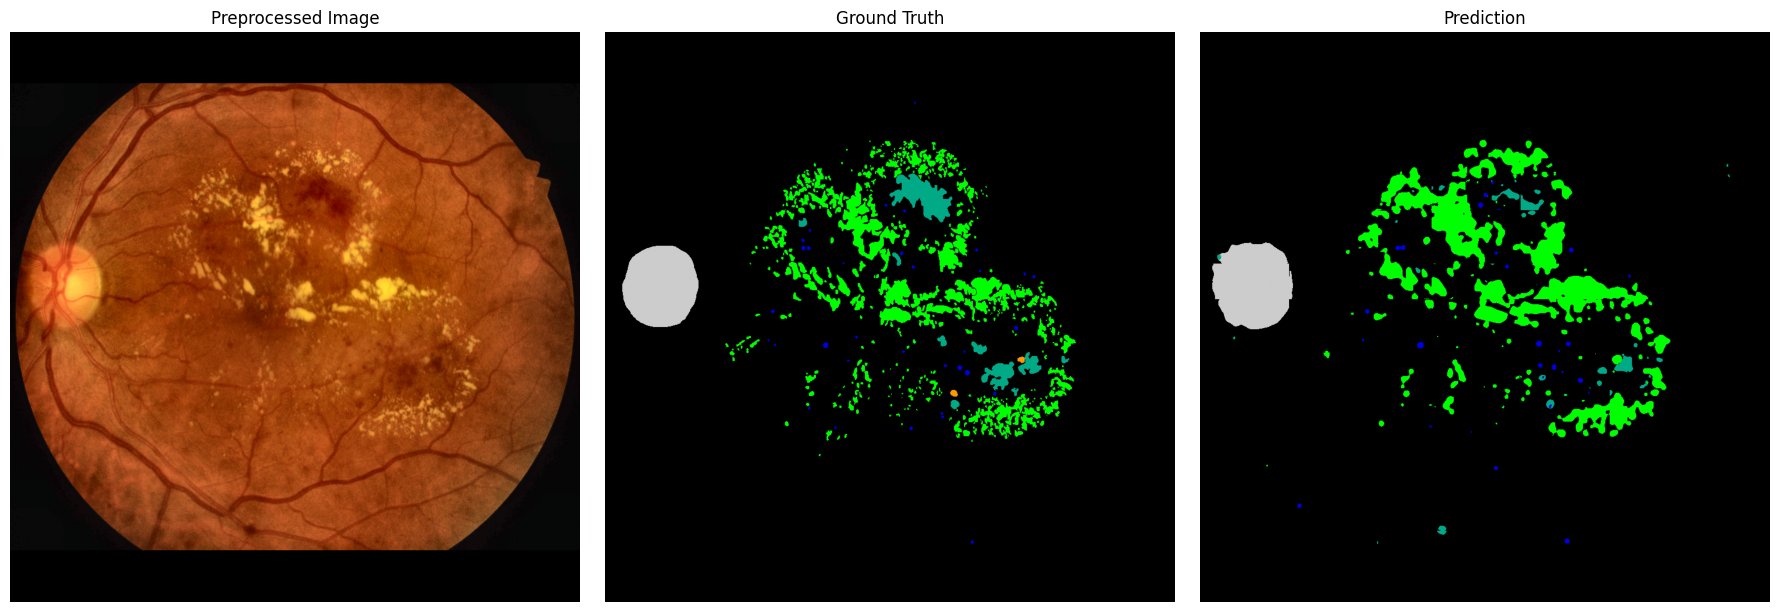

In [ ]:
idx = 0
img = test_imgs[idx]
gt  = test_masks[idx]
pred, _ = predict_full_image(best_model, img, patch_size=PATCH_SIZE, stride=160, use_tta=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img)
axes[0].set_title("Preprocessed Image")
axes[0].axis("off")

axes[1].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=num_classes - 1)
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(pred, cmap="nipy_spectral", vmin=0, vmax=num_classes - 1)
axes[2].set_title("Prediction")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# DATASET SUMMARY
# =========================

print("========== RAW SPLITS ==========")
print("Train images:", len(train_imgs))
print("Val images  :", len(val_imgs))
print("Test images :", len(test_imgs))

print("\n========== IMAGE SHAPES ==========")
print("Train image shape example:", train_imgs[0].shape)
print("Train mask shape example :", train_masks[0].shape)
print("Val image shape example  :", val_imgs[0].shape)
print("Test image shape example :", test_imgs[0].shape)

print("\n========== PATCH SETTINGS ==========")
print("Patch size        :", PATCH_SIZE)
print("Batch size        :", BATCH_SIZE)
print("Train steps/epoch :", len(train_seq))
print("Val batches       :", tf.data.experimental.cardinality(val_ds).numpy())

print("\n========== EFFECTIVE PATCH COUNT ==========")
print("Train patches per epoch:", len(train_seq) * BATCH_SIZE)
print("Val patches total      :", tf.data.experimental.cardinality(val_ds).numpy() * BATCH_SIZE)

========== RAW SPLITS ==========
Train images: 45
Val images  : 9
Test images : 27

========== IMAGE SHAPES ==========
Train image shape example: (1024, 1024, 3)
Train mask shape example : (1024, 1024)
Val image shape example  : (1024, 1024, 3)
Test image shape example : (1024, 1024, 3)

========== PATCH SETTINGS ==========
Patch size        : 256
Batch size        : 8
Train steps/epoch : 70
Val batches       : 5

========== EFFECTIVE PATCH COUNT ==========
Train patches per epoch: 560
Val patches total      : 40


In [ ]:
# =========================
# BEFORE vs AFTER PREPROCESSING
# =========================

sample_idx = 0

# Original raw image and mask
raw_img = read_rgb(train_recs[sample_idx]["image_path"])
raw_mask = combine_masks(train_recs[sample_idx]["masks"], raw_img.shape[:2])

# Preprocessed image and mask
pp_img, pp_mask = preprocess_image_and_mask(raw_img, raw_mask)

print("========== RAW ==========")
print("Raw image shape:", raw_img.shape)
print("Raw mask shape :", raw_mask.shape)
print("Raw image min/max:", raw_img.min(), raw_img.max())
print("Raw mask labels :", np.unique(raw_mask))

print("\n========== PREPROCESSED ==========")
print("Preprocessed image shape:", pp_img.shape)
print("Preprocessed mask shape :", pp_mask.shape)
print("Preprocessed image min/max:", pp_img.min(), pp_img.max())
print("Preprocessed mask labels :", np.unique(pp_mask))

========== RAW ==========
Raw image shape: (2848, 4288, 3)
Raw mask shape : (2848, 4288)
Raw image min/max: 0 255
Raw mask labels : [0 1 2 3 4 5]

========== PREPROCESSED ==========
Preprocessed image shape: (1024, 1024, 3)
Preprocessed mask shape : (1024, 1024)
Preprocessed image min/max: 0 255
Preprocessed mask labels : [0 1 2 3 4 5]


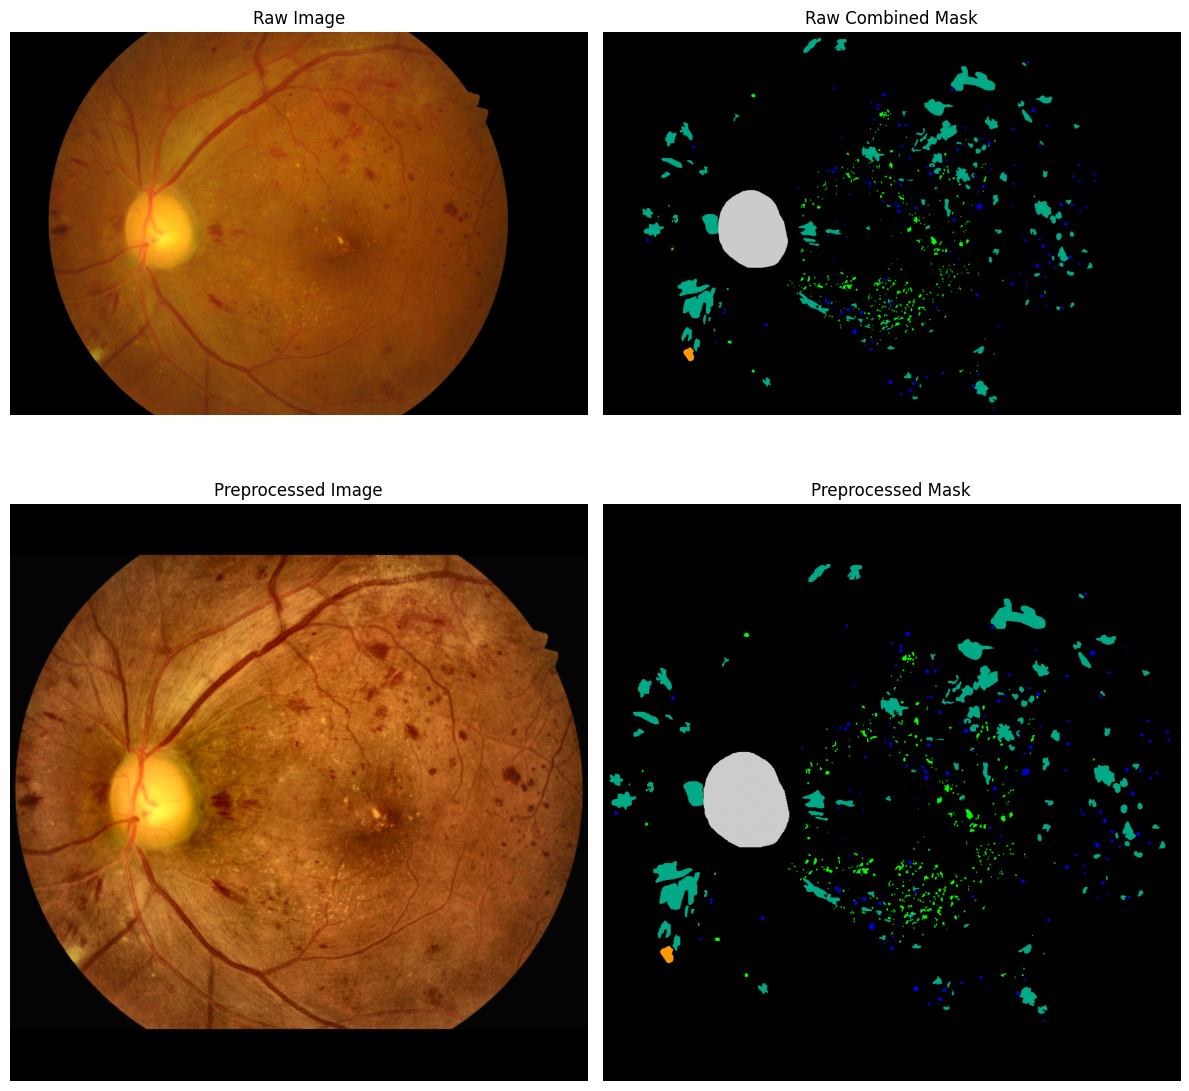

In [ ]:
# =========================
# VISUAL COMPARISON
# =========================

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(raw_img)
axes[0, 0].set_title("Raw Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(raw_mask, cmap="nipy_spectral", vmin=0, vmax=num_classes-1)
axes[0, 1].set_title("Raw Combined Mask")
axes[0, 1].axis("off")

axes[1, 0].imshow(pp_img)
axes[1, 0].set_title("Preprocessed Image")
axes[1, 0].axis("off")

axes[1, 1].imshow(pp_mask, cmap="nipy_spectral", vmin=0, vmax=num_classes-1)
axes[1, 1].set_title("Preprocessed Mask")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# CLASS DISTRIBUTION
# =========================

def class_distribution(masks, n_classes=6):
    counts = np.zeros(n_classes, dtype=np.int64)
    for m in masks:
        counts += np.bincount(m.flatten(), minlength=n_classes)
    return counts

train_class_counts = class_distribution(train_masks, num_classes)
val_class_counts   = class_distribution(val_masks, num_classes)
test_class_counts  = class_distribution(test_masks, num_classes)

dist_df = pd.DataFrame({
    "Class": [CLASS_NAMES[i] for i in range(num_classes)],
    "Train Pixels": train_class_counts,
    "Val Pixels": val_class_counts,
    "Test Pixels": test_class_counts
})

display(dist_df)

,Class,Train Pixels,Val Pixels,Test Pixels
0,Background,45295493,9117653,27173980
1,Microaneurysm,48256,12524,26756
2,Hemorrhage,511567,50071,294034
3,Hard Exudate,375749,83917,295626
4,Soft Exudate,90963,17321,48929
5,Optic Disc,863892,155698,472227


In [ ]:
# =========================
# PATCH COUNT PER IMAGE
# =========================

def count_patches_per_image(images, masks, class_indices=None, patches_per_image=4):
    total = 0
    per_image = []

    rng = np.random.default_rng(SEED)

    for i, (img, mask) in enumerate(zip(images, masks)):
        planned = [c for c in [1, 2, 3, 4, 5] if np.any(mask == c)]
        if len(planned) == 0:
            planned = [0]

        planned = planned[:patches_per_image]
        while len(planned) < patches_per_image:
            planned.append(0)

        per_image.append(len(planned))
        total += len(planned)

    return total, per_image

train_patch_total, train_patch_list = count_patches_per_image(
    train_imgs, train_masks, train_class_indices, patches_per_image=4
)

val_patch_total, val_patch_list = count_patches_per_image(
    val_imgs, val_masks, None, patches_per_image=4
)

test_patch_total, test_patch_list = count_patches_per_image(
    test_imgs, test_masks, None, patches_per_image=4
)

print("Train images:", len(train_imgs))
print("Val images  :", len(val_imgs))
print("Test images :", len(test_imgs))

print("\nPatches per image:")
print("Train:", train_patch_total, "total patches")
print("Val  :", val_patch_total, "total patches")
print("Test :", test_patch_total, "total patches")

print("\nAverage patches per image:")
print("Train:", np.mean(train_patch_list))
print("Val  :", np.mean(val_patch_list))
print("Test :", np.mean(test_patch_list))

Train images: 45
Val images  : 9
Test images : 27

Patches per image:
Train: 180 total patches
Val  : 36 total patches
Test : 108 total patches

Average patches per image:
Train: 4.0
Val  : 4.0
Test : 4.0


Patch image shape: (256, 256, 3)
Patch mask shape : (256, 256)
Patch labels     : [0 1 2]


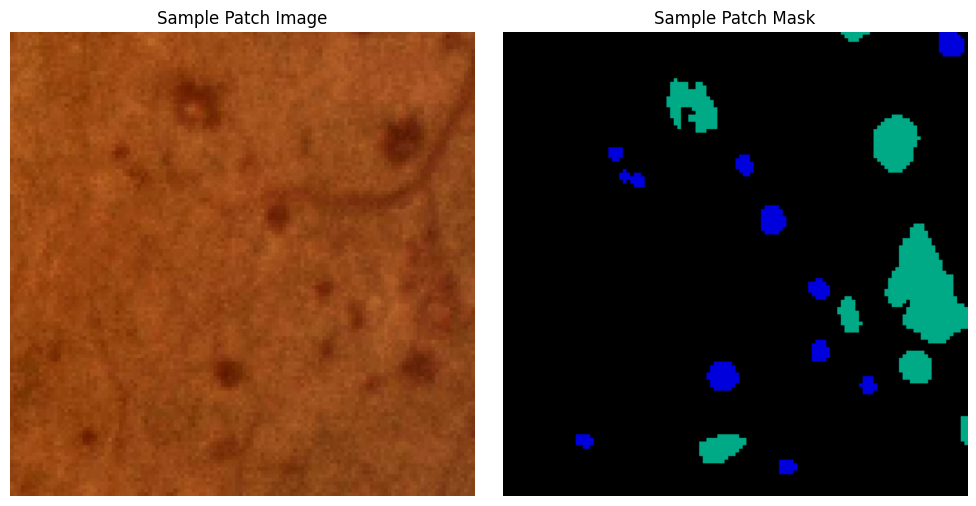

In [ ]:
# =========================
# SAMPLE TRAINING PATCH
# =========================

rng = np.random.default_rng(123)

img = train_imgs[0]
mask = train_masks[0]

# choose a class for patch sampling
chosen_class = 1 if np.any(mask == 1) else 0
patch_img, patch_mask = extract_patch_from_full(img, mask, chosen_class, rng, training=True)

print("Patch image shape:", patch_img.shape)
print("Patch mask shape :", patch_mask.shape)
print("Patch labels     :", np.unique(patch_mask))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(patch_img)
axes[0].set_title("Sample Patch Image")
axes[0].axis("off")

axes[1].imshow(patch_mask, cmap="nipy_spectral", vmin=0, vmax=num_classes-1)
axes[1].set_title("Sample Patch Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# LESION PRESENCE IN IMAGES
# =========================

def lesion_presence_count(masks, n_classes=6):
    counts = np.zeros(n_classes, dtype=np.int64)
    for m in masks:
        for c in range(1, n_classes):
            if np.any(m == c):
                counts[c] += 1
    return counts

train_presence = lesion_presence_count(train_masks, num_classes)
val_presence   = lesion_presence_count(val_masks, num_classes)
test_presence  = lesion_presence_count(test_masks, num_classes)

presence_df = pd.DataFrame({
    "Class": [CLASS_NAMES[i] for i in range(num_classes)],
    "Train Images with Class": train_presence,
    "Val Images with Class": val_presence,
    "Test Images with Class": test_presence
})

display(presence_df)

,Class,Train Images with Class,Val Images with Class,Test Images with Class
0,Background,0,0,0
1,Microaneurysm,45,9,27
2,Hemorrhage,44,9,27
3,Hard Exudate,45,9,27
4,Soft Exudate,21,5,14
5,Optic Disc,45,9,27


Best validation MA Dice seen: 0.3613026738166809
Final train foreground dice : 0.41158315539360046
Final val foreground dice   : 0.380829781293869
Final train MA dice : 0.4247090816497803
Final val MA dice   : 0.34587404131889343


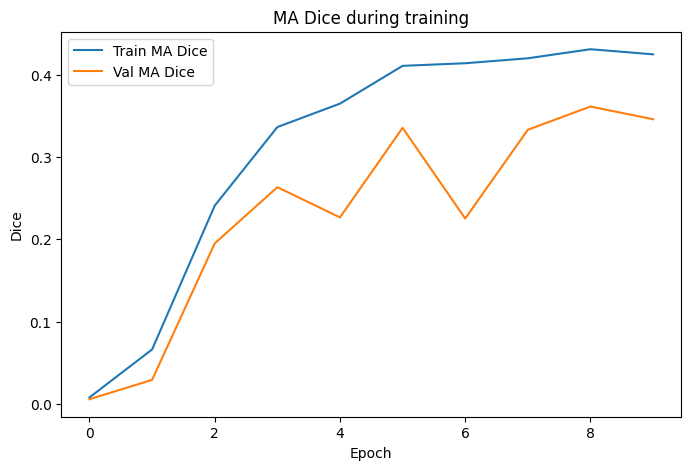

In [ ]:
# =========================
# TRAINING EFFECT SUMMARY
# =========================

print("Best validation MA Dice seen:", np.max(history1.history.get("val_segmentation_ma_dice_coef", [0])))

if "segmentation_foreground_dice_coef" in history1.history:
    print("Final train foreground dice :", history1.history["segmentation_foreground_dice_coef"][-1])
    print("Final val foreground dice   :", history1.history["val_segmentation_foreground_dice_coef"][-1])

if "segmentation_ma_dice_coef" in history1.history:
    print("Final train MA dice :", history1.history["segmentation_ma_dice_coef"][-1])
    print("Final val MA dice   :", history1.history["val_segmentation_ma_dice_coef"][-1])

plt.figure(figsize=(8, 5))
plt.plot(history1.history.get("segmentation_ma_dice_coef", []), label="Train MA Dice")
plt.plot(history1.history.get("val_segmentation_ma_dice_coef", []), label="Val MA Dice")
plt.legend()
plt.title("MA Dice during training")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.show()